# Taller de IA — Parte 2: Leer códigos QR

En la **Parte 1** (`01_mnist/codigo/01_taller_mnist.ipynb`) una red **aprendió** a leer dígitos y, en el paso 8, esa misma red corrió con **OpenCV** (`cv2.dnn`).

Aquí no hay red. En software el caso típico es al revés: **tú eliges el patrón**. Un código QR mete un texto (SKU, URL, token) en una imagen estándar. El resto de la app no mira píxeles: mira el **string** que salió del decoder. OpenCV, que ya usaste, también sabe generar y leer QR.

La pregunta del taller no cambió: *¿qué hay en esta imagen?* Aquí la respuesta es un **texto** que tu programa puede usar (buscar un producto, abrir un enlace, validar un ticket).

## Objetivo de esta parte

1. Generar un QR a partir de un string
2. Detectarlo y **decodificar** el texto
3. Conectar eso a una mini-app: catálogo de productos (visión → lógica de negocio)

No hace falta webcam. El extra del final es opcional, en casa.


## Paso 1: Preparar las herramientas

**Tarea**: Importar OpenCV, NumPy y Matplotlib (sin Keras).

**Enfoque**: `cv2` ya apareció al final de la Parte 1 para **correr** la red. Ahora no hay modelo: OpenCV lee un patrón estándar.

- **OpenCV (`cv2`)** — `QRCodeEncoder` (escribir) y `QRCodeDetector` (leer)
- **NumPy** — la imagen es un arreglo
- **Matplotlib** — ver el QR *dentro* del notebook


**Código**:

In [1]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV versión:", cv2.__version__)
print("Encoder QR:", hasattr(cv2, "QRCodeEncoder"))
print("Detector QR:", hasattr(cv2, "QRCodeDetector"))


OpenCV versión: 5.0.0
Encoder QR: True
Detector QR: True


**Resultado**: OpenCV 5.0.0 y los dos `True`. El entorno de la Parte 2 está listo. `cv2` es el mismo de la Parte 1; cambian las clases que usamos.

Siguiente: convertir un string de aplicación (un SKU) en una imagen.


## Paso 2: Generar un QR

**Tarea**: Codificar el texto `SKU-1042` en una imagen QR.

**Enfoque**: En una app el QR no es un dibujo: es un **contrato**. El backend (o este notebook) escribe un string; más tarde cualquier cámara + decoder tiene que devolver *el mismo* string.

`QRCodeEncoder.encode` produce la cuadrícula (módulos 0/255). La agrandamos con vecino más cercano — si la interpolaras suave, el detector falla — y dejamos un **margen blanco** (zona de silencio), igual que una etiqueta impresa no puede ir recortada al borde.


**Código**:

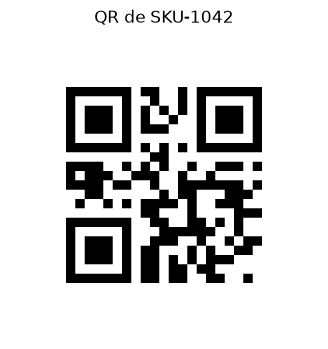

Forma: (330, 330) | texto que metimos: SKU-1042


In [2]:
encoder = cv2.QRCodeEncoder.create()
detector = cv2.QRCodeDetector()


def generar_qr(texto, modulo=10, margen_modulos=4):
    """Imagen en escala de grises de un QR que contiene `texto`."""
    nucleo = encoder.encode(texto)
    lado = nucleo.shape[0] * modulo
    img = cv2.resize(nucleo, (lado, lado), interpolation=cv2.INTER_NEAREST)
    m = margen_modulos * modulo
    return cv2.copyMakeBorder(img, m, m, m, m, cv2.BORDER_CONSTANT, value=255)


def mostrar(img, titulo=""):
    """Muestra una imagen de OpenCV (gris o BGR) en el notebook."""
    plt.figure(figsize=(4, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()


payload = "SKU-1042"
qr = generar_qr(payload)
mostrar(qr, f"QR de {payload}")
print("Forma:", qr.shape, "| texto que metimos:", payload)


**Resultado**: Un QR clásico. Para el programa, eso **es** el string `SKU-1042`, no un dibujo. Si lo imprimieras en una caja, el scanner de la caja registradora buscaría exactamente ese texto.

Siguiente: leerlo, que es el paso de visión.


## Paso 3: Detectar y decodificar

**Tarea**: Localizar el QR en la imagen y recuperar el string.

**Enfoque**: `detectAndDecode` hace las dos cosas que una app necesita:

- **dónde** — 4 esquinas en píxeles (para dibujar el recuadro en la UI)
- **qué** — el texto (para el resto del software: una query, un deep link, un token)

Si no hay QR, el texto sale vacío. En código de producción eso es un error de usuario, no una excepción de Python.


**Código**:

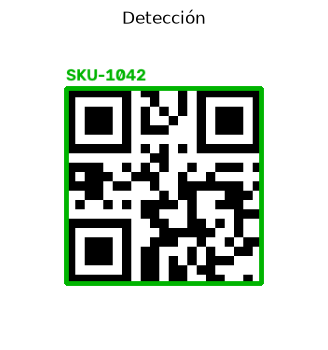

Texto leído: 'SKU-1042'
¿Coincide con lo que escribimos? True
Esquinas (píxeles):
[[ 60.  60.]
 [269.  60.]
 [269. 269.]
 [ 60. 269.]]


In [3]:
def leer_qr(img):
    """Devuelve (texto, esquinas). texto == '' si no se leyó nada."""
    texto, pts, _ = detector.detectAndDecode(img)
    return texto, pts


def dibujar_qr(img, pts, etiqueta=""):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if img.ndim == 2 else img.copy()
    if pts is not None and len(pts):
        poly = pts.astype(int).reshape(-1, 2)
        cv2.polylines(vis, [poly], True, (0, 180, 0), 3)
        x, y = poly[0]
        cv2.putText(
            vis, etiqueta or "QR", (int(x), int(y) - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 180, 0), 2, cv2.LINE_AA,
        )
    return vis


texto, pts = leer_qr(qr)
vis = dibujar_qr(qr, pts, texto)
mostrar(vis, "Detección")
print("Texto leído:", repr(texto))
print("¿Coincide con lo que escribimos?", texto == payload)
if pts is not None:
    print("Esquinas (píxeles):")
    print(np.round(pts.reshape(-1, 2), 1))


**Resultado**: El recuadro sigue al QR y el texto vuelve a ser `SKU-1042`. Ida y vuelta: string → imagen → string. A partir de aquí la visión ya terminó; lo que sigue es software.

Siguiente: usar ese string como si fuera la entrada de una app de inventario.


## Paso 4: De la imagen al catálogo

**Tarea**: “Escanear” tres productos y uno desconocido. El decoder entrega un código; un diccionario Python hace de base de datos.

**Enfoque**: En un desarrollo real la cámara y el decoder son un *adapter*. El dominio (precios, stock, 404) no sabe de OpenCV. Por eso separamos:

1. `leer_qr(img)` → string o fallo
2. `consultar(codigo)` → ficha del producto o error de negocio

Eso es visión aplicada a software: el modelo no clasifica “tornillo vs batería”; lee un código y **tu** lógica decide.


**Código**:

código    | estado | detalle


----------+--------+---------------------------
SKU-1042  | OK     | Tornillo M4  $0.15  stock=1200
SKU-2088  | OK     | Sensor ultrasónico  $8.50  stock=40
SKU-3301  | OK     | Batería 18650  $4.20  stock=0
SKU-9999  | ERROR  | Código fuera del catálogo


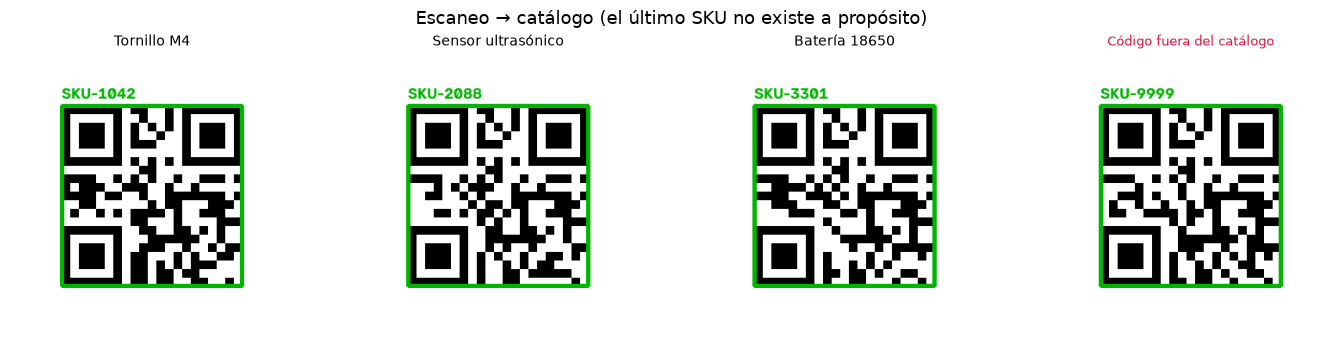

In [4]:
# Mini base de datos: lo que viviría en SQL / una API.
CATALOGO = {
    "SKU-1042": {"nombre": "Tornillo M4", "precio": 0.15, "stock": 1200},
    "SKU-2088": {"nombre": "Sensor ultrasónico", "precio": 8.50, "stock": 40},
    "SKU-3301": {"nombre": "Batería 18650", "precio": 4.20, "stock": 0},
}


def consultar(codigo):
    """Lógica de negocio: el QR ya se convirtió en texto."""
    if not codigo:
        return {"ok": False, "error": "No se leyó ningún QR"}
    item = CATALOGO.get(codigo)
    if item is None:
        return {"ok": False, "codigo": codigo, "error": "Código fuera del catálogo"}
    return {"ok": True, "codigo": codigo, **item}


def escanear(img):
    texto, pts = leer_qr(img)
    return consultar(texto), texto, pts


codigos = ["SKU-1042", "SKU-2088", "SKU-3301", "SKU-9999"]
imagenes = [generar_qr(c) for c in codigos]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
print("código    | estado | detalle")
print("----------+--------+---------------------------")
for ax, img, esperado in zip(axes, imagenes, codigos):
    ficha, texto, pts = escanear(img)
    vis = dibujar_qr(img, pts, texto or "?")
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    if ficha["ok"]:
        detalle = f"{ficha['nombre']}  ${ficha['precio']:.2f}  stock={ficha['stock']}"
        estado = "OK"
        ax.set_title(ficha["nombre"], fontsize=10)
    else:
        detalle = ficha["error"]
        estado = "ERROR"
        ax.set_title(ficha["error"], fontsize=9, color="crimson")
    print(f"{esperado:<9} | {estado:<6} | {detalle}")
plt.suptitle("Escaneo → catálogo (el último SKU no existe a propósito)", fontsize=13)
plt.tight_layout()
plt.show()


**Resultado**: Tres productos encontrados (incluido uno con stock 0: eso también es un resultado válido de negocio) y `SKU-9999` fuera del catálogo. El decoder funcionó en los cuatro; el error del último **no** es de visión, es de la app. Esa distinción es el punto de esta parte.

Con esto cierra el objetivo de la Parte 2.


## Cierre de la Parte 2

OpenCV respondió *¿qué hay en la imagen?* con un **string**. El resto fue una app mínima: buscar en un catálogo y manejar el “no está”.

### Qué aprendimos
1. Un QR es un texto empaquetado en una imagen estándar
2. Generar: string → cuadrícula → imagen con margen
3. Leer: imagen → esquinas + texto (si falla, texto vacío)
4. La visión termina en el string; precios, stock y 404 son software

### Cómo encaja en el taller

| | Parte 1 | Parte 2 (esta) | Parte 3 |
|---|---|---|---|
| Pregunta | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? |
| Respuesta | un dígito 0–9 | un texto (SKU, URL…) | un ID de estación |
| Herramienta | red que **aprendimos** | decoder QR de OpenCV | detector ArUco de OpenCV |
| Dónde se usa | patrón sucio / variable | apps, tickets, inventario | robots, almacén, pose |

### Siguiente: Parte 3

Abre `03_aruco/codigo/03_taller_aruco.ipynb`. Sigue siendo OpenCV y una etiqueta diseñada, pero ArUco no carga una URL: carga un **ID** pensado para que un robot sepa *qué estación* está viendo y *dónde* está en la foto.

### Extra: webcam (opcional, en casa)

Genera un QR en pantalla o en el celular (`SKU-1042`) y, en una celda nueva:

```python
def ver_camara():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("No hay cámara")
        return
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        texto, pts, _ = detector.detectAndDecode(frame)
        vis = frame.copy()
        if texto:
            poly = pts.astype(int).reshape(-1, 2)
            cv2.polylines(vis, [poly], True, (0, 180, 0), 2)
            cv2.putText(vis, texto, tuple(poly[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 180, 0), 2)
            print(consultar(texto))
        cv2.imshow("QR (q para salir)", vis)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    cv2.destroyAllWindows()

# ver_camara()
```
